# Système RAG Agentique — Rapports Annuels 10-K d'Apple (Domaine Finance)

Ce projet implémente un système RAG (Retrieval-Augmented Generation) agentique, construit avec LangGraph. L'agent répond à des questions sur les rapports annuels (10-K) d'Apple Inc. pour les cinq derniers exercices, récupérés depuis SEC EDGAR. Contrairement à un pipeline RAG classique, l'agent peut raisonner sur une requête, décider quand la récupération est nécessaire, choisir quel outil appeler, et router dynamiquement entre les étapes. Le système est évalué sur 10 questions simples et 10 questions complexes, en mesurant la qualité des réponses, le temps de réponse et la pertinence des documents récupérés.

## Packages

In [ ]:
!pip install -q langgraph langchain-google-genai langchain-community langchain-chroma requests pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 788.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 

In [ ]:
!pip install -q langchain-text-splitters

## Configuration de la clé API Gemini

In [29]:
import os
import getpass

# if "GOOGLE_API_KEY" not in os.environ:
os.environ["GOOGLE_API_KEY"] = getpass.getpass("Entrez votre clé API Google AI (Gemini): ")

Entrez votre clé API Google AI (Gemini): ··········


## Récupération des identifiants Apple sur SEC EDGAR

Avant de récupérer les rapports 10-K, nous devons obtenir le CIK (Central Index Key) d'Apple, l'identifiant utilisé par EDGAR pour chaque entité. Nous utilisons le fichier officiel de correspondance ticker → CIK fourni par la SEC.

In [3]:
import requests

# La SEC exige un User-Agent identifiant le demandeur (nom + email)
HEADERS = {
    "User-Agent": "Elhafiani Aya aya_elhafiani@gmail.com"
}

# Fichier officiel de correspondance ticker -> CIK
tickers_url = "https://www.sec.gov/files/company_tickers.json"
response = requests.get(tickers_url, headers=HEADERS)
response.raise_for_status()
tickers_data = response.json()

# Recherche d'Apple par ticker
apple_entry = next(
    v for v in tickers_data.values() if v["ticker"] == "AAPL"
)
apple_cik = str(apple_entry["cik_str"]).zfill(10)

print(f"Nom EDGAR : {apple_entry['title']}")
print(f"CIK (10 chiffres) : {apple_cik}")

Nom EDGAR : Apple Inc.
CIK (10 chiffres) : 0000320193


## Récupération de la liste des rapports 10-K d'Apple

Nous interrogeons l'API Submissions de la SEC pour obtenir l'historique des dépôts d'Apple, puis filtrons pour ne garder que les formulaires 10-K (rapports annuels) des cinq derniers exercices.

In [4]:
submissions_url = f"https://data.sec.gov/submissions/CIK{apple_cik}.json"
response = requests.get(submissions_url, headers=HEADERS)
response.raise_for_status()
submissions = response.json()

recent = submissions["filings"]["recent"]

# Les données sont stockées sous forme de colonnes parallèles (mêmes index)
forms = recent["form"]
dates = recent["filingDate"]
accession_numbers = recent["accessionNumber"]
primary_docs = recent["primaryDocument"]

# Filtrage des 10-K uniquement
ten_k_filings = []
for i, form in enumerate(forms):
    if form == "10-K":
        ten_k_filings.append({
            "date": dates[i],
            "accessionNumber": accession_numbers[i],
            "primaryDocument": primary_docs[i],
        })

# On garde les 5 plus récents (déjà triés du plus récent au plus ancien)
ten_k_filings = ten_k_filings[:5]

for f in ten_k_filings:
    print(f["date"], f["accessionNumber"], f["primaryDocument"])

2025-10-31 0000320193-25-000079 aapl-20250927.htm
2024-11-01 0000320193-24-000123 aapl-20240928.htm
2023-11-03 0000320193-23-000106 aapl-20230930.htm
2022-10-28 0000320193-22-000108 aapl-20220924.htm
2021-10-29 0000320193-21-000105 aapl-20210925.htm


## Construction des URLs et téléchargement des documents 10-K

Chaque URL de filing se construit à partir du CIK, du numéro d'accession (sans tirets) et du nom du document principal. Nous téléchargeons ensuite le contenu HTML de chaque rapport.

In [5]:
cik_int = int(apple_cik)  # sans zéros de tête pour l'URL

filing_urls = []
for f in ten_k_filings:
    accession_no_dashes = f["accessionNumber"].replace("-", "")
    url = f"https://www.sec.gov/Archives/edgar/data/{cik_int}/{accession_no_dashes}/{f['primaryDocument']}"
    filing_urls.append({"date": f["date"], "url": url})

for f in filing_urls:
    print(f["date"], "->", f["url"])

2025-10-31 -> https://www.sec.gov/Archives/edgar/data/320193/000032019325000079/aapl-20250927.htm
2024-11-01 -> https://www.sec.gov/Archives/edgar/data/320193/000032019324000123/aapl-20240928.htm
2023-11-03 -> https://www.sec.gov/Archives/edgar/data/320193/000032019323000106/aapl-20230930.htm
2022-10-28 -> https://www.sec.gov/Archives/edgar/data/320193/000032019322000108/aapl-20220924.htm
2021-10-29 -> https://www.sec.gov/Archives/edgar/data/320193/000032019321000105/aapl-20210925.htm


## Test d'extraction du texte — un seul rapport

Avant de traiter les cinq rapports, nous testons l'extraction de texte sur un seul document HTML afin de vérifier la qualité du résultat (texte, sections, tableaux).

In [7]:
!pip install -q html2text beautifulsoup4

In [6]:
from bs4 import BeautifulSoup
import requests # Import requests library
import html2text # Import html2text library

# Fetch the first filing URL for testing purposes
# 'filing_urls' and 'HEADERS' are available from previous cells.
resp = requests.get(filing_urls[0]["url"], headers=HEADERS)
resp.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

soup = BeautifulSoup(resp.text, "html.parser")


# Supprimer le bloc de métadonnées iXBRL (non visuel, cause du bruit)
for tag in soup.find_all("ix:header"):
    tag.decompose()

# Supprimer les éléments explicitement masqués (display:none)
for tag in soup.find_all(style=lambda v: v and "display:none" in v.replace(" ", "")):
    tag.decompose()

# Supprimer scripts/styles
for tag in soup(["script", "style"]):
    tag.decompose()

converter = html2text.HTML2Text()
converter.ignore_links = True
converter.ignore_images = True
converter.body_width = 0

text = converter.handle(str(soup))

print(f"Longueur totale du texte : {len(text)} caractères")
print("\n--- Extrait (2000 premiers caractères) ---\n")
print(text[:2000])

Longueur totale du texte : 224208 caractères

--- Extrait (2000 premiers caractères) ---

  


| |   
---|---|---  
  
UNITED STATES

SECURITIES AND EXCHANGE COMMISSION

Washington, D.C. 20549

| |   
---|---|---  
  
FORM 10-K

| |   
---|---|---  
  
(Mark One)

☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the fiscal year ended September 27, 2025

or

☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE SECURITIES EXCHANGE ACT OF 1934

For the transition period from  to  .

Commission File Number: 001-36743

| |   
---|---|---  
  
Apple Inc.

(Exact name of Registrant as specified in its charter)

| |   
---|---|---  
  
| | | | | | | |   
---|---|---|---|---|---|---|---|---  
California| | 94-2404110  
(State or other jurisdictionof incorporation or organization)| | (I.R.S. Employer Identification No.)  
| |   
One Apple Park Way| |   
Cupertino, California| | 95014  
(Address of principal executive offices)| | (Zip Code)  
  
(4

## Fonction d'extraction de texte réutilisable

Nous transformons le test précédent en une fonction que nous appliquons aux cinq rapports 10-K.

In [7]:
def extract_filing_text(html_content):
    soup = BeautifulSoup(html_content, "html.parser")

    for tag in soup.find_all("ix:header"):
        tag.decompose()
    for tag in soup.find_all(style=lambda v: v and "display:none" in v.replace(" ", "")):
        tag.decompose()
    for tag in soup(["script", "style"]):
        tag.decompose()

    converter = html2text.HTML2Text()
    converter.ignore_links = True
    converter.ignore_images = True
    converter.body_width = 0

    return converter.handle(str(soup))


filing_texts = {}  # clé = date du dépôt, valeur = texte complet

for f in filing_urls:
    resp = requests.get(f["url"], headers=HEADERS)
    resp.raise_for_status()
    filing_texts[f["date"]] = extract_filing_text(resp.text)
    print(f"{f['date']} : {len(filing_texts[f['date']])} caractères extraits")

2025-10-31 : 224208 caractères extraits
2024-11-01 : 221398 caractères extraits
2023-11-03 : 218284 caractères extraits
2022-10-28 : 233021 caractères extraits
2021-10-29 : 240570 caractères extraits


## Découpage par section ("Item")

Nous détectons les en-têtes de type "Item N." pour diviser chaque rapport 10-K en sections logiques (Business, Risk Factors, MD&A, etc.), avant d'appliquer un découpage de taille fixe à l'intérieur des sections trop longues.

In [8]:
import re

# Détecte les en-têtes du type "Item 1A.    Risk Factors" ou "Item 7. Management's..."
item_pattern = re.compile(r"(Item\s+\d+[A-Z]?\.\s+[A-Z][^\n]{3,100})", re.MULTILINE)

# Test sur le filing le plus récent uniquement, pour vérifier le découpage
sample_text = filing_texts["2025-10-31"]
matches = item_pattern.findall(sample_text)

print(f"Nombre d'en-têtes détectés : {len(matches)}")
for m in matches:
    print("-", m.strip())

Nombre d'en-têtes détectés : 22
- Item 1. Business
- Item 1A. Risk Factors
- Item 1B. Unresolved Staff Comments
- Item 1C. Cybersecurity
- Item 2. Properties
- Item 3. Legal Proceedings
- Item 4. Mine Safety Disclosures
- Item 5. Market for Registrant’s Common Equity, Related Stockholder Matters and Issuer Purchases of Equity Sec
- Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations
- Item 7A. Quantitative and Qualitative Disclosures About Market Risk
- Item 8. Financial Statements and Supplementary Data
- Item 9. Changes in and Disagreements with Accountants on Accounting and Financial Disclosure
- Item 9A. Controls and Procedures
- Item 9B. Other Information
- Item 9C. Disclosure Regarding Foreign Jurisdictions that Prevent Inspections
- Item 10. Directors, Executive Officers and Corporate Governance
- Item 11. Executive Compensation
- Item 12. Security Ownership of Certain Beneficial Owners and Management and Related Stockholder Matters
- It

## Construction des chunks avec métadonnées (section + année)

Chaque rapport est d'abord divisé en sections logiques ("Item"), puis chaque section trop longue est redécoupée en chunks de taille fixe avec chevauchement. Chaque chunk conserve des métadonnées : l'année du dépôt et la section d'origine.

In [12]:
!pip install langchain_text_splitters

In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""],
)

def split_into_sections(text):
    """Découpe le texte en (titre_section, contenu) selon les en-têtes 'Item'."""
    matches = list(item_pattern.finditer(text))
    sections = []
    for i, m in enumerate(matches):
        start = m.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        title = m.group(1).strip()
        content = text[start:end]
        sections.append((title, content))
    return sections

all_chunks = []  # liste de dicts : {text, filing_date, section}

for filing_date, text in filing_texts.items():
    sections = split_into_sections(text)
    for section_title, section_content in sections:
        sub_chunks = splitter.split_text(section_content)
        for chunk in sub_chunks:
            all_chunks.append({
                "text": chunk,
                "filing_date": filing_date,
                "section": section_title,
            })

print(f"Nombre total de chunks : {len(all_chunks)}")
print("\n--- Exemple de chunk ---")
print(all_chunks[100])

Nombre total de chunks : 1073

--- Exemple de chunk ---
{'text': '. The ultimate impact remains uncertain and will depend on several factors, including whether additional or incremental U.S. Tariffs or other measures are announced or imposed, to what extent other countries implement tariffs or other retaliatory measures in response, and the overall magnitude and duration of these measures. Trade and other international disputes can have an adverse impact on the overall macroeconomic environment and result in shifts and reductions in consumer spending and negative consumer sentiment for the Company’s products and services, all of which can further adversely affect the Company’s business and results of operations.', 'filing_date': '2025-10-31', 'section': 'Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations'}


## Création des embeddings et de la base vectorielle (Chroma)

Nous générons les embeddings de chaque chunk avec le modèle `gemini-embedding-001`, puis les stockons dans une base vectorielle Chroma locale, avec les métadonnées (année, section) conservées pour chaque chunk.



In [ ]:
# from langchain_google_genai import GoogleGenerativeAIEmbeddings
# from langchain_chroma import Chroma
# from langchain_core.documents import Document

# embeddings_model = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

# documents = [
#     Document(
#         page_content=chunk["text"],
#         metadata={"filing_date": chunk["filing_date"], "section": chunk["section"]},
#     )
#     for chunk in all_chunks
# ]

# vector_store = Chroma.from_documents(
#     documents=documents,
#     embedding=embeddings_model,
#     collection_name="apple_10k",
#     persist_directory="./chroma_apple_10k",
# )

# print(f"Nombre de documents indexés : {vector_store._collection.count()}")

## Création des embeddings avec limitation de débit

Le niveau gratuit de l'API Gemini limite les requêtes d'embedding à 100 par minute. Nous traitons les documents par petits lots avec une pause entre chaque lot, et une nouvelle tentative automatique en cas d'erreur 429.

In [ ]:
# !pip install -q tenacity

# import time
# from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
# from google.api_core.exceptions import ResourceExhausted

# vector_store = Chroma(
#     collection_name="apple_10k",
#     embedding_function=embeddings_model,
#     persist_directory="./chroma_apple_10k",
# )

# BATCH_SIZE = 20          # nombre de documents par lot
# PAUSE_SECONDS = 15       # pause entre les lots, pour rester sous 100 req/min

# @retry(
#     stop=stop_after_attempt(5),
#     wait=wait_exponential(multiplier=2, min=5, max=60),
# )
# def add_batch(batch):
#     vector_store.add_documents(batch)

# for i in range(0, len(documents), BATCH_SIZE):
#     batch = documents[i:i + BATCH_SIZE]
#     add_batch(batch)
#     print(f"Lot {i // BATCH_SIZE + 1}/{(len(documents) - 1) // BATCH_SIZE + 1} indexé ({len(batch)} chunks)")
#     time.sleep(PAUSE_SECONDS)

# print(f"\nNombre total de documents indexés : {vector_store._collection.count()}")

## Embeddings locaux (sans limite de quota)

Nous générons les embeddings en utilisnat le modèle `sentence-transformers`.

In [15]:
!pip install langchain_chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found 

In [10]:
!pip install -q "langchain-huggingface[full]"
# !rm -rf ./chroma_apple_10k   # supprime l'ancienne base (embeddings Gemini partiels)

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

embeddings_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)


documents = [
    Document(
        page_content=chunk["text"],
        metadata={"filing_date": chunk["filing_date"], "section": chunk["section"]},
    )
    for chunk in all_chunks
]

vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings_model,
    collection_name="apple_10k",
    persist_directory="./chroma_apple_10k",
)

print(f"Nombre total de documents indexés : {vector_store._collection.count()}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Nombre total de documents indexés : 1073


## Configuration du modèle LLM (Gemini)

Nous configurons `gemini-2.5-flash` comme modèle de raisonnement et de génération de l'agent. Une fonction d'appel robuste est ajoutée pour gérer automatiquement les erreurs de quota (429), en respectant le délai d'attente indiqué par l'API plutôt qu'un délai arbitraire.

In [12]:
!pip install langchain_google_genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 3.0 MB/s eta 0:00:00


In [15]:
import re
import time
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai.chat_models import ChatGoogleGenerativeAIError

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.2,   # réponses factuelles et peu créatives, adapté à un contexte financier
    max_retries=2,
)

def invoke_with_backoff(model, messages, max_attempts=4):
    """Appelle le modèle et respecte le retry_delay renvoyé par l'API en cas de 429."""
    for attempt in range(max_attempts):
        try:
            return model.invoke(messages)
        except ChatGoogleGenerativeAIError as e:
            if "429" not in str(e):
                raise
            match = re.search(r"retry_delay\s*\{\s*seconds:\s*(\d+)", str(e))
            delay = int(match.group(1)) if match else 30
            print(f"Quota atteint, nouvelle tentative dans {delay}s...")
            time.sleep(delay)
    raise RuntimeError("Échec après plusieurs tentatives (quota API).")

# Test rapide
test_response = invoke_with_backoff(llm, "Réponds en une phrase : qu'est-ce qu'un rapport 10-K ?")
print(test_response.content)

Le rapport 10-K est un rapport annuel détaillé et obligatoire que les sociétés cotées en bourse aux États-Unis déposent auprès de la SEC, présentant une vue complète de leur situation financière et de leurs activités.


## Définition des outils de l'agent

Deux outils sont créés : un outil de récupération (`retrieve_10k`) permettant de filtrer par année et/ou par section, et un outil de calcul (`calculator`) utilisant `numexpr` pour effectuer des calculs fiables (ex. variations en pourcentage entre deux années).

In [17]:
!pip install -q numexpr

import math
import numexpr
from langchain_core.tools import tool
from typing import Optional

@tool
def retrieve_10k(query: str, filing_year: Optional[str] = None, section: Optional[str] = None) -> str:
    """Recherche des passages pertinents dans les rapports 10-K d'Apple.

    Args:
        query: la question ou le sujet à rechercher.
        filing_year: année du dépôt à cibler, ex. '2024' (optionnel, recherche toutes les années si omis).
        section: nom (ou partie du nom) de la section à cibler, ex. 'Risk Factors' (optionnel).
    """
    filters = {}
    if filing_year:
        matching_dates = [d for d in filing_texts.keys() if filing_year in d]
        if matching_dates:
            filters["filing_date"] = {"$in": matching_dates}
    if section:
        # Recherche insensible à la casse sur les titres de section existants
        matching_sections = [s for s in set(c["section"] for c in all_chunks) if section.lower() in s.lower()]
        if matching_sections:
            filters["section"] = {"$in": matching_sections}

    search_kwargs = {"k": 5}
    if filters:
        if len(filters) > 1:
            search_kwargs["filter"] = {"$and": [{k: v} for k, v in filters.items()]}
        else:
            search_kwargs["filter"] = filters

    results = vector_store.similarity_search(query, **search_kwargs)
    if not results:
        return "Aucun passage pertinent trouvé."

    formatted = []
    for doc in results:
        formatted.append(
            f"[{doc.metadata['filing_date']} | {doc.metadata['section']}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(formatted)


@tool
def calculator(expression: str) -> str:
    """Calcule une expression mathématique (ex. variations en pourcentage, ratios).

    Args:
        expression: une expression mathématique valide, ex. '(391035 - 383285) / 383285 * 100'.
    """
    local_dict = {"pi": math.pi, "e": math.e}
    try:
        result = numexpr.evaluate(expression.strip(), global_dict={}, local_dict=local_dict)
        return str(result)
    except Exception as e:
        return f"Erreur de calcul : {e}"


tools = [retrieve_10k, calculator]
print(f"Outils définis : {[t.name for t in tools]}")

Outils définis : ['retrieve_10k', 'calculator']


In [18]:
# test
result = retrieve_10k.invoke({"query": "risk factors related to China", "filing_year": "2024"})
print(result)

[2024-11-01 | Item 1A. Risk Factors]
The Company’s operations are also subject to the risks of industrial accidents at its suppliers and contract manufacturers. While the Company’s suppliers are required to maintain safe working environments and operations, an industrial accident could occur and could result in serious injuries or loss of life, disruption to the Company’s business, and harm to the Company’s reputation. Major public health issues, including pandemics such as the COVID-19 pandemic, have adversely affected, and could in the future materially adversely affect, the Company due to their impact on the global economy and demand for consumer products; the imposition of protective public safety measures, such as stringent employee travel restrictions and limitations on freight services and the movement of products between regions; and disruptions in the Company’s operations, supply chain and sales and distribution channels, resulting in interruptions to the supply of current pro

## Construction du graphe LangGraph (architecture ReAct)

Le graphe définit un état partagé (`messages`), un nœud `agent` qui invoque Gemini avec les outils liés, et un nœud `tools` qui exécute les appels d'outils demandés. Une arête conditionnelle fait boucler l'agent vers les outils tant qu'il en a besoin, jusqu'à ce qu'il produise une réponse finale. Une mémoire (`InMemorySaver`) conserve l'historique de conversation par session.

In [38]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import SystemMessage


class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


SYSTEM_PROMPT = SystemMessage(content=(
    "Tu es un assistant financier spécialisé dans l'analyse des rapports annuels 10-K d'Apple Inc. "
    "IMPORTANT : les rapports disponibles couvrent les exercices fiscaux 2021, 2022, 2023, 2024 et 2025 "
    "(le rapport 2025 a été déposé le 31 octobre 2025 et couvre l'exercice clos le 27 septembre 2025). "
    "Ne suppose JAMAIS qu'une année n'est pas disponible sans avoir d'abord essayé l'outil 'retrieve_10k'. "
    "Les documents sources sont entièrement en anglais. Lorsque tu appelles l'outil 'retrieve_10k', "
    "formule TOUJOURS le paramètre 'query' en anglais (avec la terminologie financière appropriée, "
    "ex. 'total net sales', 'risk factors', 'gross margin'), même si la question de l'utilisateur est en français. "
    "Réponds ensuite à l'utilisateur dans la langue de sa question. "
    "Utilise l'outil 'calculator' pour tout calcul plutôt que de calculer toi-même. "
    "Cite systématiquement l'année du rapport et la section d'où provient l'information. "
    "Si l'information n'est vraiment pas trouvée après une recherche, dis-le clairement plutôt que d'inventer une réponse."
))

llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)


def call_model(state: AgentState):
    messages = [SYSTEM_PROMPT] + state["messages"]
    response = invoke_with_backoff(llm_with_tools, messages)
    return {"messages": [response]}


def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END


graph_builder = StateGraph(AgentState)
graph_builder.add_node("agent", call_model)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "agent")

checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

print("Graphe compilé avec succès.")

Graphe compilé avec succès.


In [20]:
#test
config = {"configurable": {"thread_id": "test-1"}}
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Quel était le chiffre d'affaires total d'Apple en 2024 ?"}]},
    config,
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': "Le chiffre d'affaires total d'Apple pour l'exercice 2024 était de 391 035 millions de dollars. (Rapport 10-K 2024, Section Item 8. Financial Statements and Supplementary Data et Section Item 7. Management’s Discussion and Analysis of Financial Condition and Results of Operations).", 'extras': {'signature': 'CssDARFNMg+u9XCz87k3/qyQkGoG0EmNX4UXMJ43AdcIdhFDqy1PBdHZq7ThGp2cWF+8yh1gV/5PkaWMpzFNGk9G7V5GklS+uCuh9JlrryqQdeJijZk1QSi1jTXhWs7hlanMtAiRzZ6ZEgLkM+CTd7nZ2WtesRuGL1g9LVVDRKQkFR8fTC6r0/0Ee21D+BuSUPGKPuS8sDIVUbmm+e5MK73PZNzu9jCOgQzWwj1roK067L5WbP8kyCiLzgvAMFzsU9oHuwYofpGPVX0udVeYcOtGAtuRMiAoMBwQB+wN3YQ6MDabxlwOMWeM+UO7SL5G8dcrrSgyVY25z/J1o5Sz32pFOqLxrHYm9sHsn3qXCh+FxzqAWPw7serasOnwe2rVOmgO4Wrhex2wc5HpD2nNp8IDl6PgfPOtqSSxRkFwY8l4OkxVa/6sBceQYCXtgL4AFYWHFaK+BMmXGc4ndrZvLDQmAhmq1r5EPtejvIErwE8YP8TlbQ5HNTVfFN6q0WE/xD6MRhOKyA0N7cmLc4Tg8gyeK74J9Tu8zn5cvtF62P422OOZH4YdVtAsBaBlQSSyCGHvPCW7hfm+od2iy1n4niRk0KafHS3wCLVIPnnY'}}]


In [ ]:
# for msg in result["messages"]:
#     print(f"--- {msg.type} ---")
#     if hasattr(msg, "tool_calls") and msg.tool_calls:
#         print("Tool calls:", msg.tool_calls)
#     print(msg.content[:500] if isinstance(msg.content, str) else msg.content)
#     print()

## Visualisation du graphe

Le graphe compilé est représenté visuellement, montrant les nœuds (`agent`, `tools`) et le flux conditionnel entre eux.

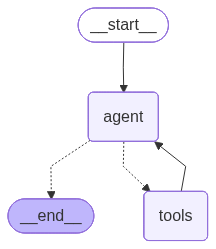

In [39]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# !pip install grandalf

## Définition du jeu de questions d'évaluation

Nous définissons les 10 questions simples et 10 questions complexes utilisées pour l'évaluation du système.

In [40]:
simple_questions = [
    "Quel était le chiffre d'affaires total d'Apple en 2024 ?",
    "Où se situe le siège social d'Apple ?",
    "Quel est le symbole boursier d'Apple et sur quelle bourse est-elle cotée ?",
    "Quelle est la valeur totale des actifs à long terme (\"long-lived assets\") d'Apple en 2024 ?",
    "Combien Apple a-t-elle réalisé de ventes nettes en Chine en 2023 ?",
    "Qui est l'auditeur indépendant d'Apple selon le rapport 2025 ?",
    "Quel numéro de dossier (Commission File Number) Apple utilise-t-elle auprès de la SEC ?",
    "Quelle est l'adresse du siège social (\"principal executive offices\") d'Apple ?",
    "Quels segments géographiques de ventes Apple rapporte-t-elle dans son 10-K de 2022 ?",
    "Quel événement lié à la cybersécurité est décrit dans l'Item 1C du rapport de 2025 ?",
]

complex_questions = [
    "Quelle a été la variation en pourcentage des ventes nettes totales d'Apple entre 2021 et 2025 ?",
    "Comment les ventes nettes en Chine ont-elles évolué entre 2022 et 2024, en pourcentage ?",
    "Compare les facteurs de risque liés à la chaîne d'approvisionnement entre les rapports 2021 et 2025 : qu'est-ce qui a changé ?",
    "L'Item 1C (Cybersecurity) n'existait pas dans les premiers rapports — depuis quelle année apparaît-il, et pourquoi cela pourrait-il être significatif ?",
    "Quelle a été la différence en valeur absolue des actifs à long terme totaux entre 2023 et 2024 ?",
    "Comment le langage sur les risques géopolitiques (Chine, tarifs douaniers) a-t-il évolué entre le rapport 2022 et le rapport 2025 ?",
    "Quelle proportion (%) des ventes nettes totales de 2024 provenait des pays autres que les États-Unis et la Chine (\"Other countries\") ?",
    "Compare le traitement des risques liés aux pandémies entre le rapport 2021 (en pleine COVID-19) et le rapport 2025 — le ton ou le contenu a-t-il changé ?",
    "Quelle a été l'évolution du nombre total de sections \"Item\" entre 2021 et 2025, et quels changements structurels cela reflète-t-il ?",
    "Si les ventes nettes en Chine ont baissé de 2022 à 2023 mais les actifs à long terme en Chine ont aussi baissé, quelle relation peut-on observer entre ces deux tendances ?",
]

all_questions = (
    [{"id": f"S{i+1}", "type": "simple", "text": q} for i, q in enumerate(simple_questions)]
    + [{"id": f"C{i+1}", "type": "complexe", "text": q} for i, q in enumerate(complex_questions)]
)

print(f"Total de questions : {len(all_questions)}")

Total de questions : 20


## Exécution des questions à travers l'agent

Pour chaque question, nous mesurons le temps de réponse, capturons les documents effectivement récupérés par l'outil `retrieve_10k`, et enregistrons la réponse finale.

In [41]:
import time

def run_question(question_text, thread_id):
    config = {"configurable": {"thread_id": thread_id}}
    start = time.time()
    result = graph.invoke(
        {"messages": [{"role": "user", "content": question_text}]},
        config,
    )
    elapsed = time.time() - start

    retrieved_chunks = []
    tool_calls_made = []
    for msg in result["messages"]:
        if getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                tool_calls_made.append({"tool": tc["name"], "args": tc["args"]})
        if msg.type == "tool":
            retrieved_chunks.append(msg.content)

    final_answer = result["messages"][-1].content
    if isinstance(final_answer, list):  # certaines réponses Gemini renvoient une liste de blocs
        final_answer = " ".join(
            block.get("text", "") for block in final_answer if isinstance(block, dict)
        )

    return {
        "response_time_sec": round(elapsed, 2),
        "tool_calls": tool_calls_made,
        "retrieved_chunks": retrieved_chunks,
        "final_answer": final_answer,
    }


evaluation_results = []
for q in all_questions:
    print(f"Traitement de {q['id']}...")
    outcome = run_question(q["text"], thread_id=f"eval-{q['id']}")
    evaluation_results.append({**q, **outcome})
    time.sleep(2)  # petite pause pour rester raisonnable sur le taux de requêtes LLM

print(f"\n{len(evaluation_results)} questions traitées.")

Traitement de S1...
Traitement de S2...
Traitement de S3...
Traitement de S4...
Traitement de S5...
Traitement de S6...
Traitement de S7...
Traitement de S8...
Traitement de S9...
Traitement de S10...
Traitement de C1...
Traitement de C2...
Traitement de C3...
Traitement de C4...
Traitement de C5...
Traitement de C6...
Traitement de C7...
Traitement de C8...
Traitement de C9...
Traitement de C10...

20 questions traitées.


In [42]:
import json

# Inspection d'un résultat simple et d'un résultat complexe
print("=== Exemple simple (S1) ===")
print(json.dumps(evaluation_results[0], indent=2, ensure_ascii=False)[:1500])
print("\n=== Exemple complexe (C1) ===")
print(json.dumps(evaluation_results[10], indent=2, ensure_ascii=False)[:1500])

=== Exemple simple (S1) ===
{
  "id": "S1",
  "type": "simple",
  "text": "Quel était le chiffre d'affaires total d'Apple en 2024 ?",
  "response_time_sec": 1.9,
  "tool_calls": [
    {
      "tool": "retrieve_10k",
      "args": {
        "query": "total net sales",
        "filing_year": "2024"
      }
    }
  ],
  "retrieved_chunks": [
    "[2024-11-01 | Item 8. Financial Statements and Supplementary Data]\n| | | | | | | | | | | | | | | | |   \n---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---  \n| Years ended  \n| September 28,  \n2024| | September 30,  \n2023| | September 24,  \n2022  \nNet sales:| | | | |   \nProducts| $| 294,866 | | | $| 298,085 | | | $| 316,199 |   \nServices| 96,169 | | | 85,200 | | | 78,129 |   \nTotal net sales| 391,035 | | | 383,285 | | | 394,328 |   \n| | | | |   \nCost of sales:| | | | |   \nProducts| 185,233 | | | 189,282 | | | 201,471 |   \nServices| 25,119 | | | 24,855 | | | 22,075 |   \nTotal cost of sales| 210,352 | | | 214,137 

In [43]:
print("=== C1 (test du correctif) ===")
print(evaluation_results[10]["final_answer"])
print("Tool calls:", evaluation_results[10]["tool_calls"])
print()
print("=== S1 (vérification format) ===")
print(evaluation_results[0]["final_answer"])

=== C1 (test du correctif) ===
Les ventes nettes totales d'Apple ont augmenté de 13,76 % entre 2021 et 2025.

En 2021, les ventes nettes totales étaient de 365 817 millions de dollars (Rapport 10-K 2021, Section "Item 8. Financial Statements and Supplementary Data").
En 2025, les ventes nettes totales étaient de 416 161 millions de dollars (Rapport 10-K 2025, Section "Item 8. Financial Statements and Supplementary Data").
Tool calls: [{'tool': 'retrieve_10k', 'args': {'query': 'total net sales', 'filing_year': '2021'}}, {'tool': 'retrieve_10k', 'args': {'filing_year': '2025', 'query': 'total net sales'}}, {'tool': 'calculator', 'args': {'expression': '((416161 - 365817) / 365817) * 100'}}]

=== S1 (vérification format) ===
Le chiffre d'affaires total d'Apple en 2024 était de 391 035 millions de dollars (391,035 milliards de dollars), comme indiqué dans la section "Item 8. Financial Statements and Supplementary Data" du rapport 10-K de 2024.


## Évaluation automatique (LLM-as-judge)

Pour chaque question, un modèle juge (Gemini) évalue deux dimensions en Pass/Fail :
1. **Pertinence des documents récupérés** : les passages récupérés contiennent-ils l'information nécessaire pour répondre ?
2. **Qualité de la réponse** : la réponse finale est-elle correcte, bien fondée sur les documents récupérés, et complète ?

Chaque évaluation inclut une justification écrite, pour permettre une validation manuelle rapide.

In [45]:
import json

JUDGE_PROMPT_TEMPLATE = """Tu es un évaluateur impartial d'un système RAG financier.

Question posée : {question}

Documents récupérés par le système :
{retrieved}

Réponse finale du système : {answer}

Évalue deux dimensions séparément :

1. PERTINENCE DES DOCUMENTS : Les documents récupérés contiennent-ils l'information nécessaire pour répondre correctement à la question ? Réponds PASS si oui, FAIL si les documents sont hors sujet ou insuffisants.

2. QUALITÉ DE LA RÉPONSE : La réponse est-elle correcte, bien fondée sur les documents récupérés (pas d'invention), et répond-elle réellement à la question posée ? Réponds PASS si oui, FAIL sinon. Si le système a refusé de répondre alors que l'information était disponible dans les documents, c'est un FAIL.

Réponds UNIQUEMENT avec un objet JSON valide, sans texte avant ou après, au format exact suivant :
{{"retrieval_verdict": "PASS ou FAIL", "retrieval_reason": "justification en une phrase", "answer_verdict": "PASS ou FAIL", "answer_reason": "justification en une phrase"}}
"""

judge_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0)

def judge_result(entry):
    if entry["retrieved_chunks"]:
        retrieved_text = "\n---\n".join(chunk[:2000] for chunk in entry["retrieved_chunks"])
    else:
        retrieved_text = "(aucun document récupéré)"

    prompt = JUDGE_PROMPT_TEMPLATE.format(
        question=entry["text"],
        retrieved=retrieved_text,
        answer=entry["final_answer"],
    )
    response = judge_llm.invoke(prompt)
    raw = response.content.strip()
    raw = raw.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"retrieval_verdict": "ERROR", "retrieval_reason": raw, "answer_verdict": "ERROR", "answer_reason": raw}


for entry in evaluation_results:
    verdict = judge_result(entry)
    entry.update(verdict)
    print(f"{entry['id']}: retrieval={verdict['retrieval_verdict']}, answer={verdict['answer_verdict']}")
    time.sleep(1)

S1: retrieval=PASS, answer=PASS
S2: retrieval=PASS, answer=PASS
S3: retrieval=PASS, answer=PASS
S4: retrieval=FAIL, answer=FAIL
S5: retrieval=PASS, answer=PASS
S6: retrieval=FAIL, answer=FAIL
S7: retrieval=FAIL, answer=PASS
S8: retrieval=FAIL, answer=FAIL
S9: retrieval=PASS, answer=PASS
S10: retrieval=FAIL, answer=PASS
C1: retrieval=PASS, answer=PASS
C2: retrieval=PASS, answer=PASS
C3: retrieval=PASS, answer=FAIL
C4: retrieval=PASS, answer=FAIL
C5: retrieval=FAIL, answer=FAIL
C6: retrieval=PASS, answer=PASS
C7: retrieval=PASS, answer=PASS
C8: retrieval=PASS, answer=PASS
C9: retrieval=PASS, answer=FAIL
C10: retrieval=FAIL, answer=FAIL


In [46]:
for entry in evaluation_results:
    print(f"--- {entry['id']} ({entry['type']}) ---")
    print(f"Question : {entry['text']}")
    print(f"Retrieval: {entry['retrieval_verdict']} — {entry['retrieval_reason']}")
    print(f"Answer:    {entry['answer_verdict']} — {entry['answer_reason']}")
    print(f"Réponse donnée : {entry['final_answer'][:300]}")
    print()

--- S1 (simple) ---
Question : Quel était le chiffre d'affaires total d'Apple en 2024 ?
Retrieval: PASS — Le premier document contient directement le chiffre d'affaires total (Total net sales) pour l'année fiscale 2024 (Years ended September 28, 2024).
Answer:    PASS — La réponse fournit le chiffre d'affaires total correct de 391 035 millions de dollars, tel qu'indiqué dans le document pour l'année fiscale 2024, et le contexte est correctement cité.
Réponse donnée : Le chiffre d'affaires total d'Apple en 2024 était de 391 035 millions de dollars (391,035 milliards de dollars), comme indiqué dans la section "Item 8. Financial Statements and Supplementary Data" du rapport 10-K de 2024.

--- S2 (simple) ---
Question : Où se situe le siège social d'Apple ?
Retrieval: PASS — Le document 'Item 2. Properties' contient l'information exacte sur l'emplacement du siège social de l'entreprise.
Answer:    PASS — La réponse est correcte, précise et entièrement fondée sur les informations fournies d

## Sauvegarde des résultats d'évaluation

Les résultats complets (réponses, documents récupérés, temps de réponse, verdicts du LLM-juge) sont exportés en JSON pour analyse et rédaction du rapport.

In [47]:
import json

with open("/content/evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, ensure_ascii=False, indent=2)

# Tableau récapitulatif pour le rapport
summary = {
    "total_questions": len(evaluation_results),
    "retrieval_pass_rate": sum(1 for e in evaluation_results if e["retrieval_verdict"] == "PASS") / len(evaluation_results),
    "answer_pass_rate": sum(1 for e in evaluation_results if e["answer_verdict"] == "PASS") / len(evaluation_results),
    "avg_response_time_sec": sum(e["response_time_sec"] for e in evaluation_results) / len(evaluation_results),
    "simple": {
        "retrieval_pass_rate": sum(1 for e in evaluation_results if e["type"] == "simple" and e["retrieval_verdict"] == "PASS") / 10,
        "answer_pass_rate": sum(1 for e in evaluation_results if e["type"] == "simple" and e["answer_verdict"] == "PASS") / 10,
        "avg_response_time_sec": sum(e["response_time_sec"] for e in evaluation_results if e["type"] == "simple") / 10,
    },
    "complexe": {
        "retrieval_pass_rate": sum(1 for e in evaluation_results if e["type"] == "complexe" and e["retrieval_verdict"] == "PASS") / 10,
        "answer_pass_rate": sum(1 for e in evaluation_results if e["type"] == "complexe" and e["answer_verdict"] == "PASS") / 10,
        "avg_response_time_sec": sum(e["response_time_sec"] for e in evaluation_results if e["type"] == "complexe") / 10,
    },
}

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "total_questions": 20,
  "retrieval_pass_rate": 0.65,
  "answer_pass_rate": 0.6,
  "avg_response_time_sec": 9.227,
  "simple": {
    "retrieval_pass_rate": 0.5,
    "answer_pass_rate": 0.7,
    "avg_response_time_sec": 4.011
  },
  "complexe": {
    "retrieval_pass_rate": 0.8,
    "answer_pass_rate": 0.5,
    "avg_response_time_sec": 14.443000000000001
  }
}
